In [36]:
from langgraph.graph import StateGraph, START, END
from langchain_groq import ChatGroq
from langchain_core.prompts import PromptTemplate
from langchain_core.output_parsers import StrOutputParser
from typing import TypedDict
from dotenv import load_dotenv

In [37]:
load_dotenv()

llm = ChatGroq(
    model="openai/gpt-oss-120b",
    temperature=0
)

llm.invoke("hi").content

'Hello! How can I help you today?'

In [38]:
class LLMState(TypedDict): 
    que: str
    ans: str

In [42]:
def ask_que(state: LLMState) -> LLMState:
    que = state['que']

    que_prompt = PromptTemplate(
        template="Answer the following question: {que}",
        input_variables="que"
    )

    chain = que_prompt | llm | StrOutputParser()

    answer = chain.invoke({"que": que})

    state['ans'] = answer

    return state

In [45]:
# graph intial
graph = StateGraph(LLMState)

# graph node add 
graph.add_node('ask_que', ask_que)

# graph edge add 
graph.add_edge(START, 'ask_que')
graph.add_edge('ask_que', END)

# graph compile
workflow = graph.compile()

initial_state = {"que": "What is the capital of gujarat"}
final_state = workflow.invoke(initial_state)
final_state['ans']

'The capital of Gujarat, a state in western India, is **Gandhinagar**.'

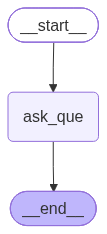

In [33]:
from IPython.display import Image
Image(workflow.get_graph().draw_mermaid_png())